In [31]:
import enerhabitat as eh
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [33]:
np.linspace(0,1,100)

array([0.        , 0.01010101, 0.02020202, 0.03030303, 0.04040404,
       0.05050505, 0.06060606, 0.07070707, 0.08080808, 0.09090909,
       0.1010101 , 0.11111111, 0.12121212, 0.13131313, 0.14141414,
       0.15151515, 0.16161616, 0.17171717, 0.18181818, 0.19191919,
       0.2020202 , 0.21212121, 0.22222222, 0.23232323, 0.24242424,
       0.25252525, 0.26262626, 0.27272727, 0.28282828, 0.29292929,
       0.3030303 , 0.31313131, 0.32323232, 0.33333333, 0.34343434,
       0.35353535, 0.36363636, 0.37373737, 0.38383838, 0.39393939,
       0.4040404 , 0.41414141, 0.42424242, 0.43434343, 0.44444444,
       0.45454545, 0.46464646, 0.47474747, 0.48484848, 0.49494949,
       0.50505051, 0.51515152, 0.52525253, 0.53535354, 0.54545455,
       0.55555556, 0.56565657, 0.57575758, 0.58585859, 0.5959596 ,
       0.60606061, 0.61616162, 0.62626263, 0.63636364, 0.64646465,
       0.65656566, 0.66666667, 0.67676768, 0.68686869, 0.6969697 ,
       0.70707071, 0.71717172, 0.72727273, 0.73737374, 0.74747

In [19]:

epw_file = "../epw/MEX_CAM_Campeche-Ignacio.766961_TMYx.epw"

wall = eh.System(eh.Location(epw_file))
wall.azimuth = 90
wall.tilt = 90
wall.absortance = 1
wall.layers = [("adobe", 0.30)]
wall.location.meanDay(month=5, year=2026)
wall.Tsa()

# # Free-running solution
sinac = wall.solve()

# # Attach Tsa to the result. Note that Tsa is a function of color, tilt,
# # orientation, month and location, so it must be recomputed whenever any of
# # those inputs change.
sinac = pd.concat([sinac, wall.Tsa().asfreq("10min")], axis=1)
sinac

,Ti,zenith,elevation,azimuth,equation_of_time,Ta,Ig,Ib,Id,Tn,DeltaTn,Is,Tsa
2026-05-15 00:00:00-06:00,31.159278,141.288454,-51.288454,0.604608,3.669781,26.732596,0.0,0.0,0.0,29.397028,1.25,0.0,26.732596
2026-05-15 00:10:00-06:00,31.168038,141.184523,-51.184523,4.379313,3.669692,26.595541,0.0,0.0,0.0,29.397028,1.25,0.0,26.595541
2026-05-15 00:20:00-06:00,31.176427,140.926771,-50.926771,8.120450,3.669602,26.461228,0.0,0.0,0.0,29.397028,1.25,0.0,26.461228
2026-05-15 00:30:00-06:00,31.184436,140.518215,-50.518215,11.800987,3.669511,26.329786,0.0,0.0,0.0,29.397028,1.25,0.0,26.329786
2026-05-15 00:40:00-06:00,31.192055,139.963478,-49.963478,15.396613,3.669420,26.201343,0.0,0.0,0.0,29.397028,1.25,0.0,26.201343
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-15 23:10:00-06:00,31.111010,139.296962,-49.296962,342.311910,3.652909,27.454287,0.0,0.0,0.0,29.397028,1.25,0.0,27.454287
2026-05-15 23:20:00-06:00,31.121439,139.941255,-49.941255,345.820174,3.652755,27.305554,0.0,0.0,0.0,29.397028,1.25,0.0,27.305554
2026-05-15 23:30:00-06:00,31.131559,140.443949,-50.443949,349.425736,3.652601,27.158878,0.0,0.0,0.0,29.397028,1.25,0.0,27.158878
2026-05-15 23:40:00-06:00,31.141357,140.799591,-50.799591,353.106904,3.652447,27.014400,0.0,0.0,0.0,29.397028,1.25,0.0,27.014400


In [30]:
sinac

,Ti,zenith,elevation,azimuth,equation_of_time,Ta,Ig,Ib,Id,Tn,DeltaTn,Is,Tsa
2026-05-15 00:00:00-06:00,31.159278,141.288454,-51.288454,0.604608,3.669781,26.732596,0.0,0.0,0.0,29.397028,1.25,0.0,26.732596
2026-05-15 00:10:00-06:00,31.168038,141.184523,-51.184523,4.379313,3.669692,26.595541,0.0,0.0,0.0,29.397028,1.25,0.0,26.595541
2026-05-15 00:20:00-06:00,31.176427,140.926771,-50.926771,8.120450,3.669602,26.461228,0.0,0.0,0.0,29.397028,1.25,0.0,26.461228
2026-05-15 00:30:00-06:00,31.184436,140.518215,-50.518215,11.800987,3.669511,26.329786,0.0,0.0,0.0,29.397028,1.25,0.0,26.329786
2026-05-15 00:40:00-06:00,31.192055,139.963478,-49.963478,15.396613,3.669420,26.201343,0.0,0.0,0.0,29.397028,1.25,0.0,26.201343
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-15 23:10:00-06:00,31.111010,139.296962,-49.296962,342.311910,3.652909,27.454287,0.0,0.0,0.0,29.397028,1.25,0.0,27.454287
2026-05-15 23:20:00-06:00,31.121439,139.941255,-49.941255,345.820174,3.652755,27.305554,0.0,0.0,0.0,29.397028,1.25,0.0,27.305554
2026-05-15 23:30:00-06:00,31.131559,140.443949,-50.443949,349.425736,3.652601,27.158878,0.0,0.0,0.0,29.397028,1.25,0.0,27.158878
2026-05-15 23:40:00-06:00,31.141357,140.799591,-50.799591,353.106904,3.652447,27.014400,0.0,0.0,0.0,29.397028,1.25,0.0,27.014400


In [22]:
wall = eh.System(eh.Location(epw_file))
wall.azimuth = 90
wall.tilt = 90
wall.absortance = 1
wall.layers = [("adobe", 0.30)]
wall.location.meanDay(month=5, year=2026)
wall.Tsa()

# Air-conditioned solution: setpoint at the upper comfort bound
conac = wall.solveAC()
conac = pd.concat([conac, wall.Tsa().asfreq("10min")], axis=1)

# Cooling and heating energy demands, in J/(m²·day) over one average day
print(wall.cooling_energy, wall.heating_energy)


210255.91356566016 0.0


In [54]:
calentamiento = []
enfriamiento = []
absortancia = []
for absortance in np.linspace(0.01,1,10):
    wall = eh.System(eh.Location(epw_file))
    wall.azimuth = 90
    wall.tilt = 90
    wall.absortance = absortance
    wall.layers = [("adobe", 0.3)]
    wall.location.meanDay(month=5, year=2026)
    wall.Tsa()
    
    # Air-conditioned solution: setpoint at the upper comfort bound
    conac = wall.solveAC()
    conac = pd.concat([conac, wall.Tsa().asfreq("10min")], axis=1)
    
    # Cooling and heating energy demands, in J/(m²·day) over one average day
    absortancia.append(absortance)
    enfriamiento.append( wall.cooling_energy)
    calentamiento.append( wall.heating_energy)


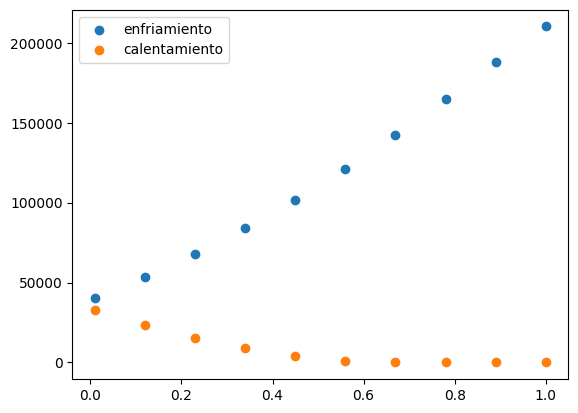

In [55]:
fig, ax = plt.subplots()
ax.scatter(absortancia,enfriamiento,label="enfriamiento")
ax.scatter(absortancia,calentamiento,label="calentamiento")

ax.legend()